# Data loading

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("CollegeScores4yr.csv")
df.dropna(subset=['CompRate'], inplace=True)
df.drop(columns=['Accred', 'State', 'MainDegree'], inplace=True)
cols_with_na = ['AdmitRate', 'MidACT', 'AvgSAT']
na_flags = df[cols_with_na].isna().astype(int).add_suffix('_na')
df = pd.concat([df, na_flags], axis=1)
df.head()

,Name,ID,Main,HighDegree,Control,Region,Locale,Latitude,Longitude,AdmitRate,...,InstructFTE,FacSalary,FullTimeFac,Pell,CompRate,Debt,PctWomen,AdmitRate_na,MidACT_na,AvgSAT_na
0,Alabama A & M University,100654,1,4,Public,Southeast,City,34.783368,-86.568502,68.4,...,7073.0,8651.0,70.6,65.4,26.8,31000.0,59.5,0,0,0
1,University of Alabama at Birmingham,100663,1,4,Public,Southeast,City,33.505697,-86.799345,86.7,...,15256.0,11837.0,75.3,33.1,64.4,22300.0,62.5,0,0,0
2,Amridge University,100690,1,4,Private,Southeast,City,32.362609,-86.174010,NaN,...,5927.0,4134.0,100.0,77.7,50.0,32189.0,63.6,1,1,1
3,University of Alabama in Huntsville,100706,1,4,Public,Southeast,City,34.724557,-86.640449,78.1,...,8733.0,10267.0,65.0,21.7,62.9,20705.0,40.2,0,0,0
4,Alabama State University,100724,1,4,Public,Southeast,City,32.364317,-86.295677,96.6,...,9349.0,8071.0,69.6,69.8,27.7,31000.0,64.0,0,0,0


# Part I: Tree-based methods

In [3]:
# a
train_df, test_df = train_test_split(df, test_size=0.3, random_state=598)
meta_train = train_df[['ID', 'Name']]
meta_test = test_df[['ID', 'Name']]

train_df = train_df.drop(columns=['ID', 'Name']).copy()
test_df = test_df.drop(columns=['ID', 'Name']).copy()

# Fill numerical n/a with median
medians = train_df.median(numeric_only=True)
train_df.fillna(medians, inplace=True)
test_df.fillna(medians, inplace=True)

# Fill categorical n/a with mode
modes = train_df.select_dtypes(include='object').mode().iloc[0]
train_df.fillna(modes, inplace=True)
test_df.fillna(modes, inplace=True)

# Map any unseen categories in test to training mode
for col in modes.index:
    train_levels = set(train_df[col].unique())
    mode_val = modes[col]
    test_df[col] = test_df[col].apply(lambda x: x if x in train_levels else mode_val)

/var/folders/n5/wz31rvqd33q6chtntps3fjn40000gn/T/ipykernel_90069/3810283333.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  modes = train_df.select_dtypes(include='object').mode().iloc[0]


In [4]:
# a.i
global_mean = train_df['CompRate'].mean()
test_pred_i = pd.Series(global_mean, index=test_df.index)
mse_i = mean_squared_error(test_df['CompRate'], test_pred_i)

# a.ii
control_means = train_df.groupby('Control')['CompRate'].mean()
test_pred_ii = test_df['Control'].map(control_means)
mse_ii = mean_squared_error(test_df['CompRate'], test_pred_ii)

print(f"Baseline (i) Test MSE: {mse_i:.5f}")
print(f"Baseline (ii) Test MSE: {mse_ii:.5f}")

Baseline (i) Test MSE: 405.40954
Baseline (ii) Test MSE: 397.95367


In [5]:
# One hot encode categorical data
train_df = pd.get_dummies(train_df, columns=modes.index, dtype=int)
test_df = pd.get_dummies(test_df, columns=modes.index, dtype=int)

X_train = train_df.drop(columns=['CompRate']).copy()
y_train = train_df['CompRate'].copy()

X_test = test_df.drop(columns=['CompRate']).copy()
y_test = test_df['CompRate'].copy()

train_df.head()

,Main,HighDegree,Latitude,Longitude,AdmitRate,MidACT,AvgSAT,Online,Enrollment,White,...,Control_Public,Region_Midwest,Region_Northeast,Region_Southeast,Region_Territories,Region_West,Locale_City,Locale_Rural,Locale_Suburb,Locale_Town
1694,1,4,35.347785,-97.578297,77.65,24.0,1150.0,0,1415,49.4,...,0,0,0,0,0,1,1,0,0,0
529,1,3,31.178616,-92.414409,57.70,20.0,1019.0,0,3600,59.9,...,1,0,0,1,0,0,0,1,0,0
719,1,4,44.972851,-93.235464,74.90,30.0,1355.0,0,30560,61.1,...,1,1,0,0,0,0,1,0,0,0
401,1,4,39.823431,-84.915037,73.20,28.0,1261.0,0,589,56.5,...,0,1,0,0,0,0,0,0,0,1
1094,1,4,46.882917,-102.799679,72.00,19.0,1018.0,0,1148,77.2,...,1,1,0,0,0,0,0,0,0,1


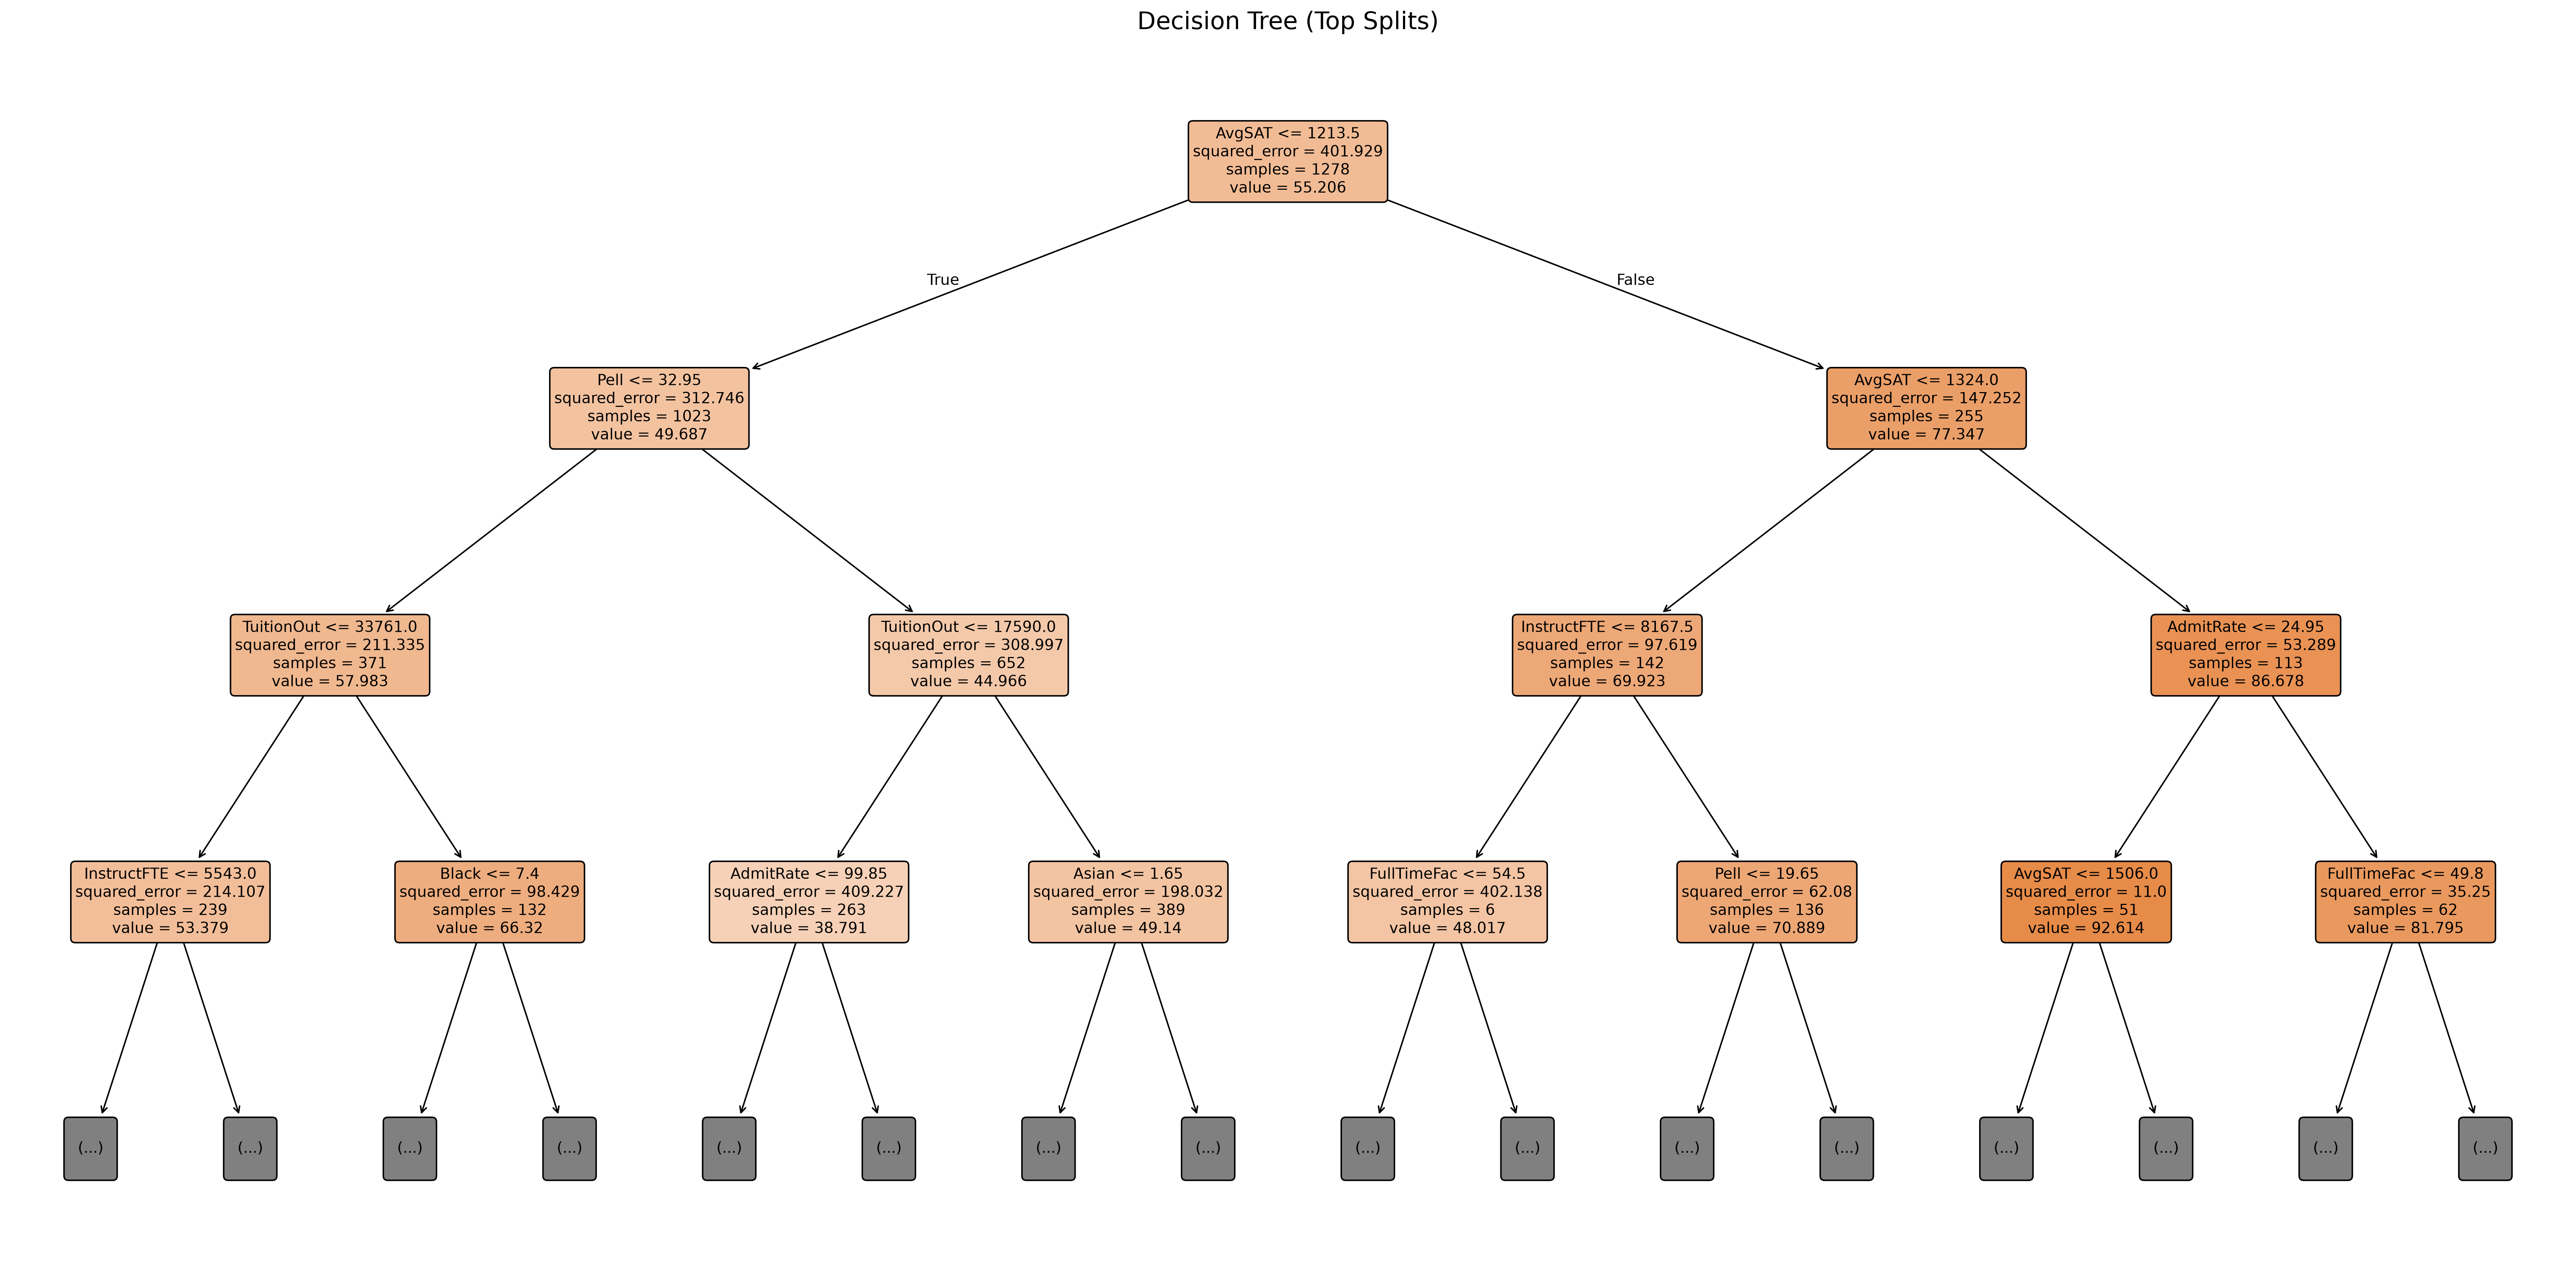

In [6]:
# b
tree_b = DecisionTreeRegressor(random_state=598)
path_b = tree_b.cost_complexity_pruning_path(X_train, y_train)
tree_b.fit(X_train, y_train)
test_pred_b = tree_b.predict(X_test)
mse_b = mean_squared_error(y_test, test_pred_b)

plt.figure(figsize=(24, 12), dpi=300)  # Large size + high resolution
plot_tree(
    tree_b,
    feature_names=X_train.columns,
    max_depth=3,           # Shows only the top 3 levels so text isn't microscopic
    filled=True,           # Colors nodes by predicted value
    rounded=True,
    fontsize=10,
    precision=3
)
plt.title("Decision Tree (Top Splits)", fontsize=16)
plt.tight_layout()
plt.show()

Split 1: AvgSAT <= 1213.5
  - Schools with average SAT scores above 1213.5 split to the right and are predicted a completion rate of ~77%, while schools with lower SAT scores split left and are predicted a lower completion rate of ~50%.
  - This split reflects selectivity by measuring SAT scores.
  
Split 2: Pell <= 32.95
  - The left child node of split 1 reflects student mix by using Pell Grant share of the students.
  - Schools with a lower share of Pell Grant students have a greater completion rate of ~58 in contrast with ~44 for schools serving higher need student populations.

In [7]:
# c
alphas_b = path_b.ccp_alphas
alphas_b = alphas_b[alphas_b >= 0][:-1]
param_grid = {'ccp_alpha': alphas_b}
grid_search = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=598),
    param_grid=param_grid,
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
test_pred_c = grid_search.predict(X_test)
mse_c = mean_squared_error(y_test, test_pred_c)

print(f"Unpruned Test MSE: {mse_b:.5f}")
print(f"Pruned Test MSE: {mse_c:.5f}")

train_public_mask = X_train['Control_Public'] == 1
X_train_public = X_train[train_public_mask]
y_train_public = y_train[train_public_mask]

tree_2c = DecisionTreeRegressor(random_state=598)
tree_2c.fit(X_train_public, y_train_public)
test_pred_2c = tree_2c.predict(X_test)
mse_2c = mean_squared_error(y_test, test_pred_2c)

print(f"Public unpruned Test MSE: {mse_2c:.5f}")

Unpruned Test MSE: 320.42303
Pruned Test MSE: 210.12378
Public unpruned Test MSE: 139.24075


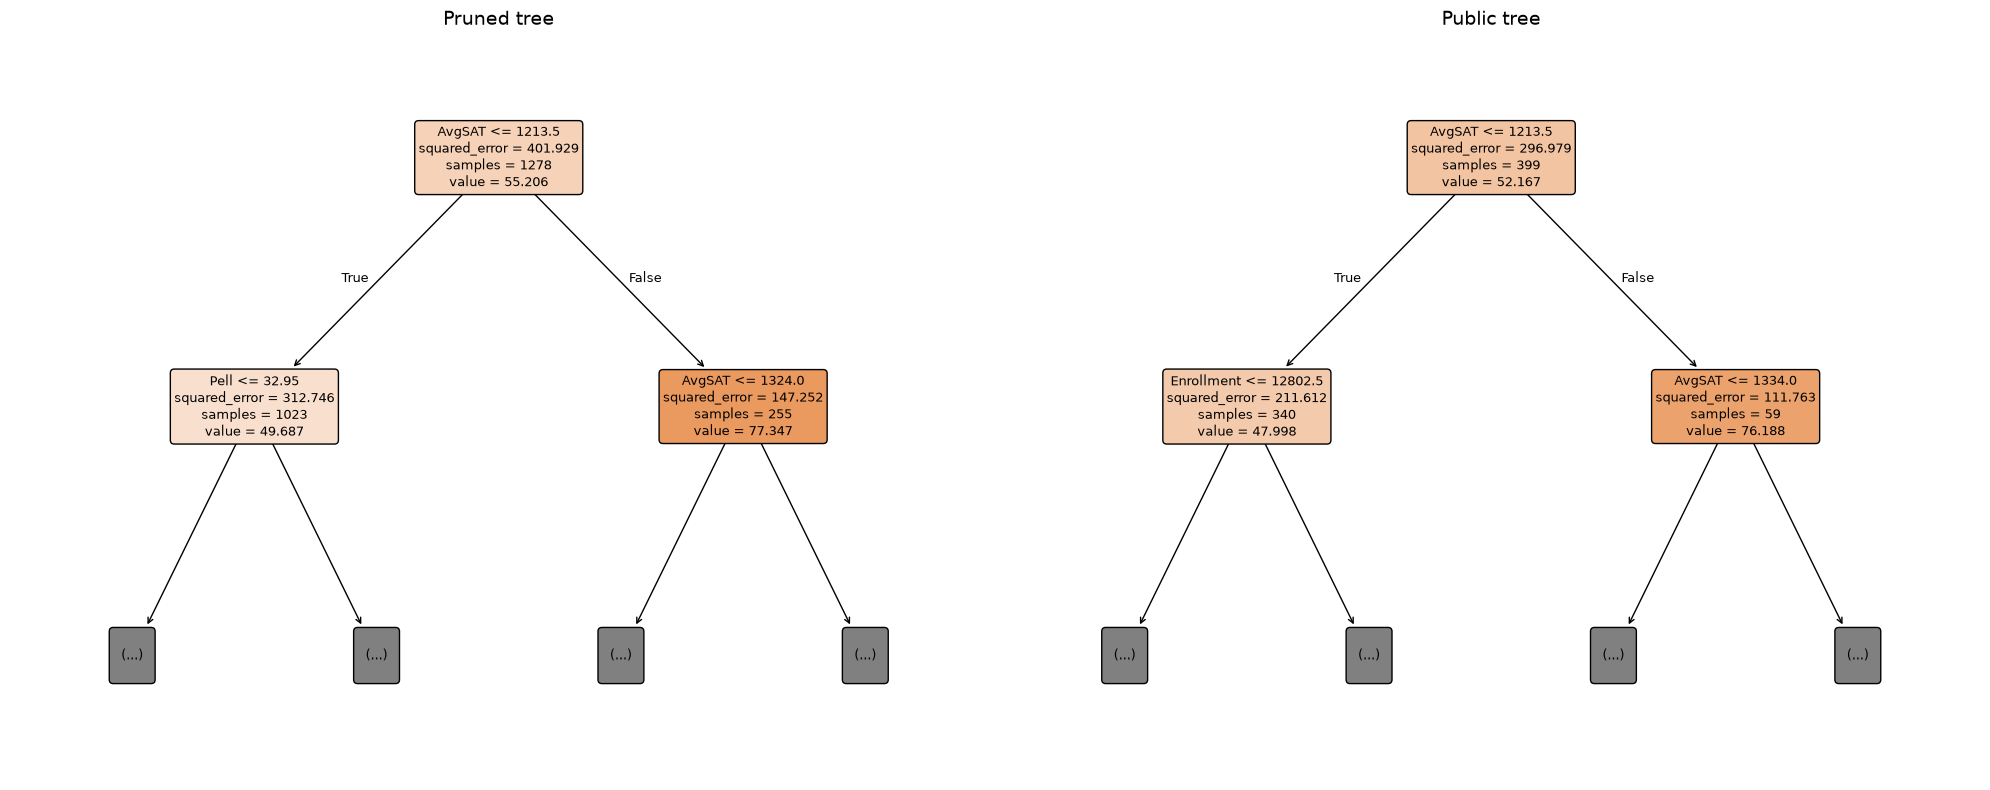

In [23]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(20, 8))

plot_tree(
    grid_search.best_estimator_,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=1,
    ax=axes[0]
)
axes[0].set_title("Pruned tree", fontsize=14)

plot_tree(
    tree_2c,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    max_depth=1,
    ax=axes[1]
)
axes[1].set_title("Public tree", fontsize=14)

# 4. Adjust layout and display
plt.tight_layout()
plt.show()

In [ ]:
# d

full_forest = RandomForestRegressor(max_features=len(X_train.columns))
full_forest.fit(X_train, y_train)

half_forest = RandomForestRegressor(max_features=int(len(X_train.columns) / 2))
half_forest.fit(X_train, y_train)

Random Forest with 41 max features test MSE: 148.58384
Random Forest with 20 max features test MSE: 155.67115


In [ ]:
# e
# TODO

In [ ]:
# f
test_pred_full_forest = full_forest.predict(X_test)
mse_full_forest = mean_squared_error(y_test, test_pred_full_forest)

test_pred_half_forest = half_forest.predict(X_test)
mse_half_forest = mean_squared_error(y_test, test_pred_half_forest)

print(f"Random Forest with {len(X_train.columns)} max features test MSE: {mse_full_forest:.5f}")
print(f"Random Forest with {int(len(X_train.columns) / 2)} max features test MSE: {mse_half_forest:.5f}")